### Enhancing Next-Day Stock Price Movement Prediction Using Technical Indicators and Financial News Sentiment

### Author
- Manas Patil

### Project Overview

Predicting stock market movements is a challenging task due to the dynamic and noisy nature of financial markets. Traditional forecasting methods primarily rely on historical price patterns and technical indicators, often overlooking valuable information embedded in financial news.

This project investigates whether incorporating financial news sentiment extracted using the FinBERT transformer model can improve the prediction of next-day stock price movements. Historical stock market data is combined with technical indicators and sentiment features to build machine learning models capable of forecasting market direction.

Four supervised learning algorithms are evaluated: Logistic Regression, Random Forest, XGBoost, and Multi-Layer Perceptron (MLP). Their predictive performance is assessed using both machine learning metrics (Accuracy, Precision, Recall, F1-score, ROC-AUC) and financial performance metrics (Cumulative Return, Sharpe Ratio, Maximum Drawdown). Additionally, the proposed trading strategy is compared against a Buy-and-Hold benchmark.

The primary objective is to determine whether financial news sentiment provides measurable predictive value beyond traditional technical indicators while maintaining a realistic evaluation framework that minimizes data leakage and look-ahead bias.

In [1]:

# Standard Libraries


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from datetime import datetime


import matplotlib.pyplot as plt
import seaborn as sns


# Yahoo Finance


import yfinance as yf



from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier


# Evaluation Metrics


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)


# Feature Importance


from sklearn.inspection import permutation_importance

In [2]:

# Project Configuration


RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

TICKERS = [
    "AAPL",
    "MSFT",
    "AMZN",
    "GOOGL",
    "NVDA"
]

START_DATE = "2011-03-03"
END_DATE = "2020-06-10"

TEST_SIZE = 0.20

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### Project Workflow

The project follows the workflow below:

1. Collect historical stock market data from Yahoo Finance.
2. Load financial news sentiment generated using FinBERT.
3. Perform data cleaning and preprocessing.
4. Engineer technical indicators.
5. Merge technical and sentiment features.
6. Train machine learning models.
7. Evaluate predictive performance.
8. Simulate a trading strategy.
9. Compare strategy performance against a Buy-and-Hold benchmark.
10. Analyze results and discuss findings.

### Data Collection

Reliable and high-quality financial data is fundamental to developing predictive machine learning models. In this project, historical stock market data is obtained from Yahoo Finance using the `yfinance` Python library.

The selected companies represent large-cap technology firms with high trading volume and significant market influence:

- Apple (AAPL)
- Amazon (AMZN)
- Alphabet (GOOGL)
- Nvidia (NVDA)

For each stock, the following daily information is collected:

- Open Price
- High Price
- Low Price
- Close Price
- Adjusted Close Price (if available)
- Trading Volume

The downloaded data serves as the foundation for feature engineering and model development.

In [3]:
# Download Historical Market Data


market_data = []

for ticker in TICKERS:

    print(f"Downloading {ticker}...")

    df = yf.download(
        ticker,
        start=START_DATE,
        end=END_DATE,
        progress=False,
        auto_adjust=False,
        group_by="column"
    )

    # Remove MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.reset_index()

    df["Ticker"] = ticker

    market_data.append(df)

print("Download Complete.")

Download Complete.


In [4]:
# Combine All Stocks

market_df = pd.concat(
    market_data,
    ignore_index=True
)

market_df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2011-03-03,10.763582,12.841429,12.849643,12.711429,12.756786,500788400,AAPL
1,2011-03-04,10.776753,12.857143,12.867500,12.776786,12.859643,453266800,AAPL
2,2011-03-07,10.637855,12.691429,12.916786,12.546786,12.907143,546123200,AAPL
3,2011-03-08,10.649826,12.705714,12.764286,12.580357,12.675357,356316800,AAPL
4,2011-03-09,10.551334,12.588214,12.670000,12.521429,12.667500,453306000,AAPL


In [5]:

# Dataset Information


print("Columns:")
print(market_df.columns)

print("\n")

print("Missing Values:")
print(market_df.isnull().sum())

print("\n")

market_df.describe()

Columns:
Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Ticker'],
      dtype='object', name='Price')


Missing Values:
Price
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Ticker       0
dtype: int64




Price,Date,Adj Close,Close,High,Low,Open,Volume
count,11665,11665.000000,11665.000000,11665.000000,11665.000000,11665.000000,1.166500e+04
mean,2015-10-20 11:07:13.604800768,33.373671,35.336551,35.659315,34.977062,35.326075,1.845430e+08
min,2011-03-03 00:00:00,0.260522,0.284500,0.290750,0.278750,0.287250,7.425600e+06
25%,2013-06-27 00:00:00,12.028651,12.899500,13.020500,12.750000,12.898929,4.162330e+07
50%,2015-10-20 00:00:00,25.189051,27.740000,28.000000,27.430000,27.749001,8.520400e+07
75%,2018-02-13 00:00:00,46.888046,49.029999,49.422501,48.581501,49.006001,2.460760e+08
max,2020-06-09 00:00:00,180.403671,189.800003,190.699997,187.259995,190.649994,3.692928e+09
std,NaN,31.145164,32.482343,32.791914,32.124871,32.467235,2.348487e+08


In [6]:

# Verify Date Range


print("Earliest Date :", market_df["Date"].min())
print("Latest Date   :", market_df["Date"].max())

print("\nStocks in Dataset:")

print(market_df["Ticker"].unique())

Earliest Date : 2011-03-03 00:00:00
Latest Date   : 2020-06-09 00:00:00

Stocks in Dataset:
['AAPL' 'MSFT' 'AMZN' 'GOOGL' 'NVDA']


In [7]:

# Save Raw Market Data

market_df.to_csv(
    "raw_market_data.csv",
    index=False
)

print("Raw dataset saved successfully.")

Raw dataset saved successfully.


### Data Validation

Before proceeding to feature engineering, the dataset is inspected to verify:

- Successful download for all selected stocks.
- Correct date range.
- Presence of expected market variables.
- Missing values that may require preprocessing.

This validation step helps ensure data quality before technical indicators are computed.

### Feature Engineering

Raw stock prices contain limited predictive information for machine learning models. To better capture market behavior, several technical indicators are derived from historical price and volume data.

The engineered features represent different aspects of market dynamics, including:

- Price trends
- Momentum
- Market volatility
- Relative price movement
- Trading activity

All features are calculated using historical observations only to prevent look-ahead bias and ensure that no future information is used during prediction.

In [8]:

# Prepare Dataset


market_df = market_df.sort_values(
    by=["Ticker", "Date"]
).reset_index(drop=True)

market_df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2011-03-03,10.763582,12.841429,12.849643,12.711429,12.756786,500788400,AAPL
1,2011-03-04,10.776753,12.857143,12.867500,12.776786,12.859643,453266800,AAPL
2,2011-03-07,10.637855,12.691429,12.916786,12.546786,12.907143,546123200,AAPL
3,2011-03-08,10.649826,12.705714,12.764286,12.580357,12.675357,356316800,AAPL
4,2011-03-09,10.551334,12.588214,12.670000,12.521429,12.667500,453306000,AAPL


In [9]:
print(market_df.columns)

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Ticker'],
      dtype='object', name='Price')


In [10]:
print(type(market_df["Close"]))

<class 'pandas.core.series.Series'>


In [11]:

# Daily Percentage Return


market_df["Return"] = (
    market_df.groupby("Ticker")["Close"]
             .pct_change()
)

In [12]:

# Moving Averages


for window in [10, 20, 50]:

    market_df[f"SMA_{window}"] = (
        market_df.groupby("Ticker")["Close"]
                 .transform(lambda x: x.rolling(window).mean())
    )

### Feature Engineering

Financial markets are inherently noisy, and raw stock prices often provide limited predictive power for machine learning models. To better represent market behavior, technical indicators are derived from historical price and volume data.

The engineered features are grouped into five categories:

- **Trend Features:** Capture long-term and short-term market direction.
- **Momentum Features:** Measure the strength of price movements.
- **Volatility Features:** Quantify market uncertainty.
- **Volume Features:** Reflect changes in trading activity.
- **Lag Features:** Preserve temporal dependencies without introducing future information.

All features are computed using historical observations only to avoid look-ahead bias and ensure a realistic prediction framework.

In [13]:

# Feature Engineering Function


def create_features(df):
    """
    Generate technical indicators for each stock.
    """

    df = df.copy()

    # Sort by ticker and date
    df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

    # Daily Return
    df["Return"] = (
        df.groupby("Ticker")["Close"]
          .pct_change()
    )

    # Moving Averages
    for window in [10, 20, 50]:
        df[f"SMA_{window}"] = (
            df.groupby("Ticker")["Close"]
              .transform(lambda x: x.rolling(window).mean())
        )

    # Exponential Moving Average
    df["EMA_20"] = (
        df.groupby("Ticker")["Close"]
          .transform(lambda x: x.ewm(span=20, adjust=False).mean())
    )

    # Volatility
    df["Volatility_20"] = (
        df.groupby("Ticker")["Return"]
          .transform(lambda x: x.rolling(20).std())
    )

    # Momentum
    df["Momentum_10"] = (
        df.groupby("Ticker")["Close"]
          .pct_change(10)
    )

    # Lag Returns
    for lag in [1, 2, 3]:
        df[f"Lag_Return_{lag}"] = (
            df.groupby("Ticker")["Return"]
              .shift(lag)
        )

    # High-Low Range
    df["High_Low_Range"] = (
        (df["High"] - df["Low"]) / df["Close"]
    )

    # Open-Close Difference
    df["Open_Close_Diff"] = (
        (df["Close"] - df["Open"]) / df["Open"]
    )

    # Volume Change
    df["Volume_Change"] = (
        df.groupby("Ticker")["Volume"]
          .pct_change()
    )

    return df

In [14]:

# Relative Strength Index (RSI)


def compute_rsi(close, window=14):

    delta = close.diff()

    gain = delta.where(delta > 0, 0)

    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window).mean()

    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / avg_loss

    return 100 - (100 / (1 + rs))

In [15]:

# MACD


def compute_macd(close):

    ema12 = close.ewm(span=12, adjust=False).mean()

    ema26 = close.ewm(span=26, adjust=False).mean()

    macd = ema12 - ema26

    signal = macd.ewm(span=9, adjust=False).mean()

    return macd, signal

In [16]:

# Add RSI and MACD


market_df = create_features(market_df)

market_df["RSI"] = (
    market_df.groupby("Ticker")["Close"]
             .transform(compute_rsi)
)

market_df["MACD"] = np.nan
market_df["Signal_Line"] = np.nan

for ticker in market_df["Ticker"].unique():

    mask = market_df["Ticker"] == ticker

    macd, signal = compute_macd(
        market_df.loc[mask, "Close"]
    )

    market_df.loc[mask, "MACD"] = macd.values
    market_df.loc[mask, "Signal_Line"] = signal.values

In [17]:

# Create Target Variable


market_df["Target"] = (
    market_df.groupby("Ticker")["Close"]
             .shift(-1)
             .gt(market_df["Close"])
             .astype(int)
)


In [18]:

# Remove Missing Values


market_df = market_df.dropna().reset_index(drop=True)

print(f"Final Dataset Shape: {market_df.shape}")

market_df.head()

Final Dataset Shape: (11420, 25)


Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Return,SMA_10,SMA_20,SMA_50,EMA_20,Volatility_20,Momentum_10,Lag_Return_1,Lag_Return_2,Lag_Return_3,High_Low_Range,Open_Close_Diff,Volume_Change,RSI,MACD,Signal_Line,Target
0,2011-05-12,10.374719,12.377500,12.397143,12.223929,12.361429,322000000,AAPL,-0.001901,12.423000,12.324054,12.305343,12.358507,0.010683,-0.000519,-0.006353,0.005322,0.002712,0.013994,0.001300,-0.041667,42.537051,0.045180,0.038697,0
1,2011-05-13,10.193013,12.160714,12.366071,12.155357,12.345000,326116000,AAPL,-0.017514,12.388607,12.338482,12.291729,12.339670,0.011173,-0.027504,-0.001901,-0.006353,0.005322,0.017327,-0.014928,0.012783,30.098630,0.023346,0.035627,0
2,2011-05-16,9.977476,11.903571,12.186429,11.878571,12.114286,449775200,AAPL,-0.021145,12.342250,12.348911,12.272657,12.298136,0.011721,-0.037484,-0.017514,-0.001901,-0.006353,0.025863,-0.017394,0.379188,26.248603,-0.014540,0.025593,1
3,2011-05-17,10.062493,12.005000,12.005000,11.811786,11.857143,452334400,AAPL,0.008521,12.299179,12.356571,12.258929,12.270219,0.011496,-0.034635,-0.021145,-0.017514,-0.001901,0.016094,0.012470,0.005690,31.857056,-0.035965,0.013282,1
4,2011-05-18,10.174154,12.138214,12.180357,12.000000,12.016786,334776400,AAPL,0.011097,12.264536,12.360161,12.247579,12.257647,0.011035,-0.027748,0.008521,-0.021145,-0.017514,0.014859,0.010105,-0.259892,41.165874,-0.041715,0.002282,1


### Financial News Sentiment Integration

To evaluate whether financial news improves next-day stock prediction, the daily sentiment features generated using FinBERT are merged with the engineered technical indicators. The merge is performed using the trading date and stock ticker as common keys, ensuring that sentiment information is aligned with the corresponding market observations while preserving chronological order.

In [19]:
daily_sentiment = pd.read_csv("daily_sentiment.csv")

In [20]:
market_df["Date"] = pd.to_datetime(market_df["Date"])
daily_sentiment["Date"] = pd.to_datetime(daily_sentiment["Date"])

In [21]:
stocks = [
    "AAPL",
    "AMZN",
    "GOOGL",
    "NVDA"
]

market_df = market_df[
    market_df["Ticker"].isin(stocks)
].copy()

In [22]:
print("Market:")
print(market_df["Date"].min())
print(market_df["Date"].max())

print()

print("Sentiment:")
print(daily_sentiment["Date"].min())
print(daily_sentiment["Date"].max())

Market:
2011-05-12 00:00:00
2020-06-09 00:00:00

Sentiment:
2011-03-03 00:00:00
2020-06-10 00:00:00


In [23]:

# Merge Technical + Sentiment Features


market_df = market_df.merge(
    daily_sentiment,
    on=["Date", "Ticker"],
    how="left"
)

print(market_df.shape)

market_df.head()

(9136, 31)


,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Return,SMA_10,SMA_20,SMA_50,EMA_20,Volatility_20,Momentum_10,Lag_Return_1,Lag_Return_2,Lag_Return_3,High_Low_Range,Open_Close_Diff,Volume_Change,RSI,MACD,Signal_Line,Target,Avg_Sentiment,Sentiment_STD,News_Count,Positive_Ratio,Neutral_Ratio,Negative_Ratio
0,2011-05-12,10.374719,12.377500,12.397143,12.223929,12.361429,322000000,AAPL,-0.001901,12.423000,12.324054,12.305343,12.358507,0.010683,-0.000519,-0.006353,0.005322,0.002712,0.013994,0.001300,-0.041667,42.537051,0.045180,0.038697,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-05-13,10.193013,12.160714,12.366071,12.155357,12.345000,326116000,AAPL,-0.017514,12.388607,12.338482,12.291729,12.339670,0.011173,-0.027504,-0.001901,-0.006353,0.005322,0.017327,-0.014928,0.012783,30.098630,0.023346,0.035627,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2011-05-16,9.977476,11.903571,12.186429,11.878571,12.114286,449775200,AAPL,-0.021145,12.342250,12.348911,12.272657,12.298136,0.011721,-0.037484,-0.017514,-0.001901,-0.006353,0.025863,-0.017394,0.379188,26.248603,-0.014540,0.025593,1,NaN,NaN,NaN,NaN,NaN,NaN
3,2011-05-17,10.062493,12.005000,12.005000,11.811786,11.857143,452334400,AAPL,0.008521,12.299179,12.356571,12.258929,12.270219,0.011496,-0.034635,-0.021145,-0.017514,-0.001901,0.016094,0.012470,0.005690,31.857056,-0.035965,0.013282,1,NaN,NaN,NaN,NaN,NaN,NaN
4,2011-05-18,10.174154,12.138214,12.180357,12.000000,12.016786,334776400,AAPL,0.011097,12.264536,12.360161,12.247579,12.257647,0.011035,-0.027748,0.008521,-0.021145,-0.017514,0.014859,0.010105,-0.259892,41.165874,-0.041715,0.002282,1,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
sentiment_cols = [
    "Avg_Sentiment",
    "Sentiment_STD",
    "News_Count",
    "Positive_Ratio",
    "Neutral_Ratio",
    "Negative_Ratio"
]

market_df[sentiment_cols].isnull().sum()

Avg_Sentiment     7511
Sentiment_STD     7511
News_Count        7511
Positive_Ratio    7511
Neutral_Ratio     7511
Negative_Ratio    7511
dtype: int64

In [25]:
market_df["News_Count"] = market_df["News_Count"].fillna(0)

market_df["Sentiment_STD"] = market_df["Sentiment_STD"].fillna(0)

market_df["Avg_Sentiment"] = market_df["Avg_Sentiment"].fillna(0)

market_df["Positive_Ratio"] = market_df["Positive_Ratio"].fillna(0)

market_df["Negative_Ratio"] = market_df["Negative_Ratio"].fillna(0)

market_df["Neutral_Ratio"] = market_df["Neutral_Ratio"].fillna(1)

In [26]:
print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(market_df.shape)

print("\n")

print("=" * 60)
print("Data Types")
print("=" * 60)
print(market_df.dtypes)

print("\n")

print("=" * 60)
print("Missing Values")
print("=" * 60)
print(market_df.isnull().sum())

Dataset Shape
(9136, 31)


Data Types
Date               datetime64[ns]
Adj Close                 float64
Close                     float64
High                      float64
Low                       float64
Open                      float64
Volume                      int64
Ticker                     object
Return                    float64
SMA_10                    float64
SMA_20                    float64
SMA_50                    float64
EMA_20                    float64
Volatility_20             float64
Momentum_10               float64
Lag_Return_1              float64
Lag_Return_2              float64
Lag_Return_3              float64
High_Low_Range            float64
Open_Close_Diff           float64
Volume_Change             float64
RSI                       float64
MACD                      float64
Signal_Line               float64
Target                      int64
Avg_Sentiment             float64
Sentiment_STD             float64
News_Count                float64
Positive_R

Target
1    4811
0    4325
Name: count, dtype: int64


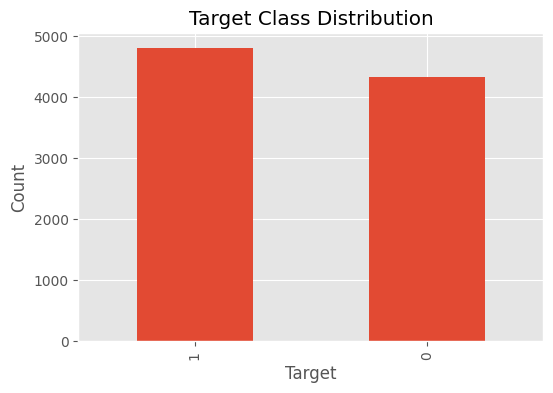

In [27]:
target_counts = market_df["Target"].value_counts()

print(target_counts)

target_counts.plot(
    kind="bar",
    figsize=(6,4),
    title="Target Class Distribution"
)

plt.ylabel("Count")
plt.show()

Figure 1 illustrates the distribution of the binary target variable used for next-day stock price movement prediction. The dataset contains 4,811 observations where the next day's closing price increased (Target = 1) and 4,325 observations where the price either decreased or remained unchanged (Target = 0).

The class distribution is relatively balanced, with approximately 52.7% positive observations and 47.3% negative observations. Although a slight majority of trading days resulted in positive price movements, the imbalance is modest and is unlikely to introduce substantial bias during model training.

Because the two classes are reasonably well represented, no additional class-balancing techniques such as oversampling, undersampling, or synthetic data generation (SMOTE) were applied. This allows the machine learning models to learn directly from the observed market behavior while preserving the natural class distribution.

The near-balanced target distribution also supports the use of standard classification metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC to evaluate predictive performance. Reporting multiple metrics remains important because financial prediction models often exhibit asymmetric behavior, particularly when distinguishing profitable trading opportunities from normal market fluctuations.

Overall, the target distribution provides a suitable foundation for binary classification and enables a fair comparison of the predictive performance of the technical-indicator-only and FinBERT-enhanced machine learning models.

In [28]:
market_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,9136,2015-11-25 00:50:26.269702144,2011-05-12 00:00:00,2013-08-19 18:00:00,2015-11-23 12:00:00,2018-03-02 18:00:00,2020-06-09 00:00:00,NaN
Adj Close,9136.0,27.485081,0.260522,8.80925,20.827294,40.5581,130.042999,24.896429
Close,9136.0,28.239847,0.2845,8.822312,21.982757,41.838376,130.042999,25.025446
High,9136.0,28.505384,0.29075,8.970375,22.174,42.127375,131.321503,25.26366
Low,9136.0,27.947436,0.27875,8.697375,21.821912,41.45275,126.25,24.752161
Open,9136.0,28.232507,0.28725,8.814625,21.994979,41.803124,126.472,25.009858
Volume,9136.0,217481544.260508,10412000.0,59677000.0,114807078.0,304477000.0,3692928000.0,243645610.860585
Return,9136.0,0.001198,-0.187559,-0.007871,0.000914,0.01076,0.298067,0.020268
SMA_10,9136.0,28.115614,0.2932,8.802894,21.907495,41.649062,123.72115,24.881145
SMA_20,9136.0,27.98115,0.297062,8.8373,21.890134,41.513888,122.366851,24.731681


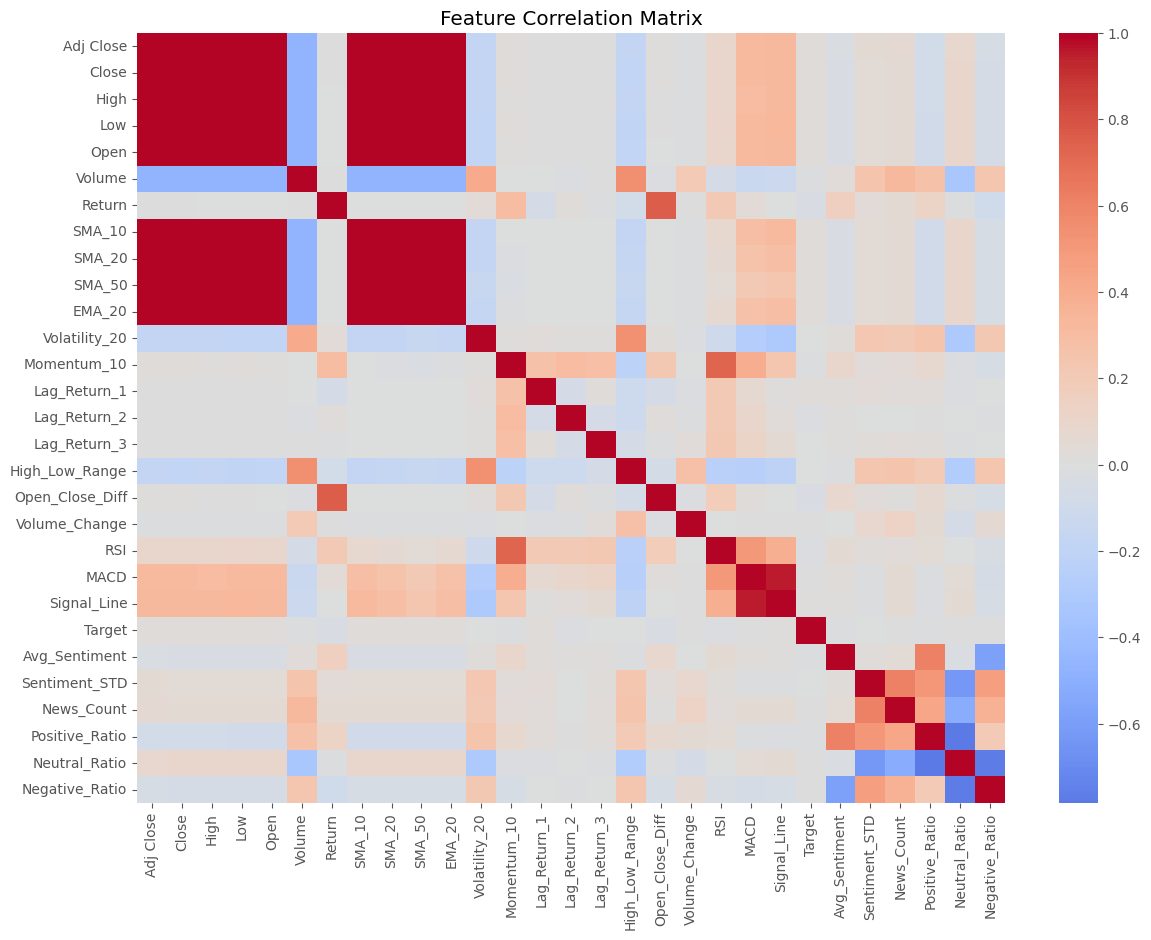

In [29]:
numeric_df = market_df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

Figure 2 presents the correlation matrix for all numerical variables used in the study, including technical indicators, FinBERT-derived sentiment features, and the binary target variable.

As expected, the raw price variables (Open, High, Low, Close, and Adjusted Close) exhibit extremely strong positive correlations with one another because they represent different measurements of the same trading session. Similarly, the moving averages (SMA-10, SMA-20, SMA-50) and the exponential moving average (EMA-20) are highly correlated with the underlying price variables, reflecting their shared dependence on historical price trends.

Momentum-based indicators also display meaningful relationships. The Relative Strength Index (RSI) shows a moderate positive correlation with Momentum_10, while MACD and the MACD Signal Line exhibit an exceptionally strong positive correlation because the Signal Line is calculated directly as an exponential moving average of the MACD values. These relationships confirm that the technical indicators were computed correctly and capture complementary aspects of market trend and momentum.

Volatility, lagged returns, High–Low Range, Open–Close Difference, and Volume Change demonstrate comparatively weaker correlations with the trend-following indicators, suggesting that these variables provide additional information rather than simply duplicating existing features. Such diversity is beneficial because tree-based models such as Random Forest and XGBoost can exploit nonlinear interactions among features even when linear correlations are relatively weak.

The FinBERT-derived sentiment variables exhibit logical relationships with one another. Positive_Ratio is positively associated with Avg_Sentiment, while Negative_Ratio shows the opposite pattern. News_Count displays a moderate positive relationship with the sentiment ratios, indicating that days containing more financial news generally produce stronger aggregate sentiment signals. Neutral_Ratio is negatively correlated with both Positive_Ratio and Negative_Ratio because the three proportions collectively represent the daily distribution of sentiment classes.

Finally, the target variable demonstrates only weak linear correlations with both the technical indicators and the sentiment features. This is consistent with the behavior of financial markets, where next-day price movements are influenced by numerous interacting factors rather than a single dominant predictor. The relatively weak pairwise correlations justify the use of nonlinear machine learning models, which are capable of learning complex relationships that cannot be captured through simple linear analysis.

Overall, the correlation matrix indicates that the engineered feature set captures multiple dimensions of market behavior—including price trends, momentum, volatility, trading activity, and financial news sentiment—providing a comprehensive foundation for evaluating whether sentiment information contributes additional predictive value beyond traditional technical indicators.

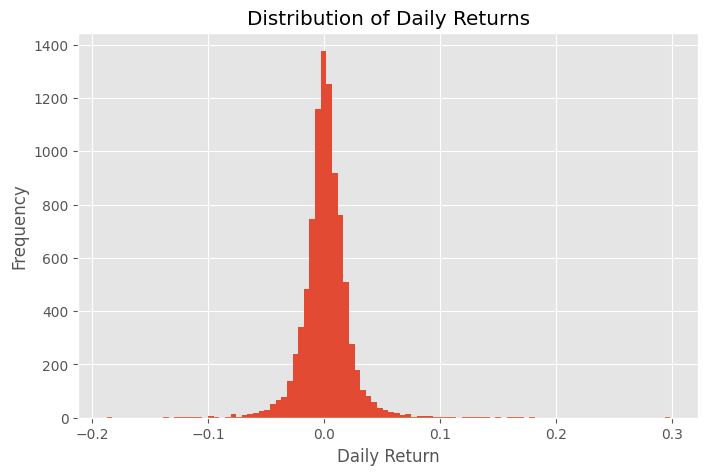

In [30]:
plt.figure(figsize=(8,5))

market_df["Return"].hist(
    bins=100
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

Distribution of Daily Returns

Figure 3 illustrates the distribution of daily stock returns across all observations in the dataset. The histogram exhibits a pronounced peak centered near zero, indicating that most trading days experience relatively small price changes. This behavior is characteristic of large-cap technology stocks, where modest day-to-day fluctuations occur far more frequently than substantial price movements.

The distribution is approximately symmetric around zero but displays noticeably heavy tails on both the positive and negative sides. These tails represent relatively infrequent periods of elevated market volatility, during which stock prices experience unusually large gains or losses. Such observations are consistent with major market events, earnings announcements, macroeconomic developments, and periods of heightened investor uncertainty.

The concentration of observations near zero, combined with the presence of extreme positive and negative returns, demonstrates that financial return series deviate from a normal distribution. This heavy-tailed behavior is a well-known characteristic of equity markets and highlights the challenges associated with next-day stock price prediction.

From a machine learning perspective, the return distribution suggests that most observations provide only weak directional signals, while relatively few trading days exhibit large movements that are easier to distinguish. Consequently, nonlinear learning algorithms such as Random Forest, XGBoost, and Multi-Layer Perceptron are appropriate because they can capture complex relationships that traditional linear models may fail to identify.

Overall, the daily return distribution confirms that the dataset reflects realistic market dynamics, containing a large number of small daily fluctuations interspersed with occasional periods of substantial volatility. These characteristics provide a challenging yet representative environment for evaluating whether combining technical indicators with FinBERT-derived financial news sentiment can improve next-day stock movement prediction.

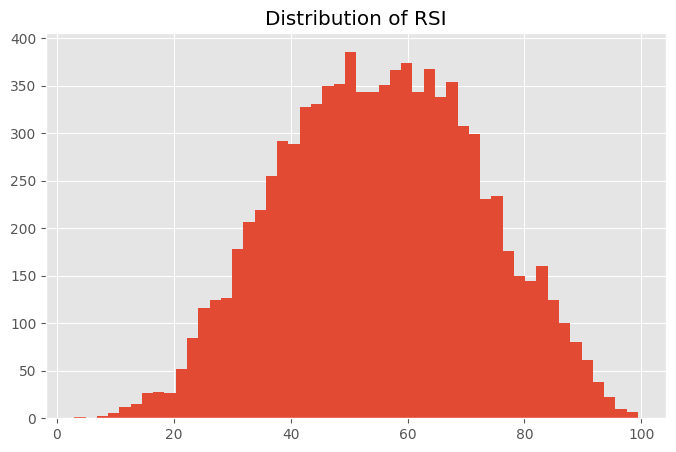

In [31]:
plt.figure(figsize=(8,5))

market_df["RSI"].hist(
    bins=50
)

plt.title("Distribution of RSI")

plt.show()

Distribution of Relative Strength Index (RSI)

Figure 4 presents the distribution of the Relative Strength Index (RSI) across all observations in the dataset. The histogram shows that most RSI values fall between 40 and 70, with the highest concentration occurring around 50 to 65. This indicates that the majority of trading days experienced moderate market momentum rather than extreme buying or selling pressure.

Only a relatively small proportion of observations fall below the conventional oversold threshold (RSI < 30) or above the overbought threshold (RSI > 70). This suggests that extreme market conditions occurred infrequently during the study period, while most observations reflected stable or gradually changing price momentum. Such behavior is consistent with large-cap technology stocks, which typically exhibit sustained trends interrupted by comparatively fewer abrupt reversals.

The broad spread of RSI values demonstrates that the indicator captures meaningful variation in market momentum without being concentrated within a narrow range. This variability provides useful information for machine learning models by enabling them to distinguish between different momentum regimes and their potential relationship with subsequent price movements.

Although RSI provides valuable information regarding market momentum, the earlier correlation analysis showed that no individual technical indicator exhibits a strong linear relationship with the target variable. Consequently, RSI is most informative when considered alongside other technical indicators and FinBERT-derived sentiment features, allowing nonlinear machine learning algorithms to exploit interactions among multiple sources of information rather than relying on a single predictor.

Overall, the RSI distribution confirms that the engineered momentum feature behaves as expected and contributes meaningful information to the predictive feature set. Combined with trend, volatility, trading activity, and financial news sentiment, RSI forms an important component of the integrated feature representation used for next-day stock movement prediction.

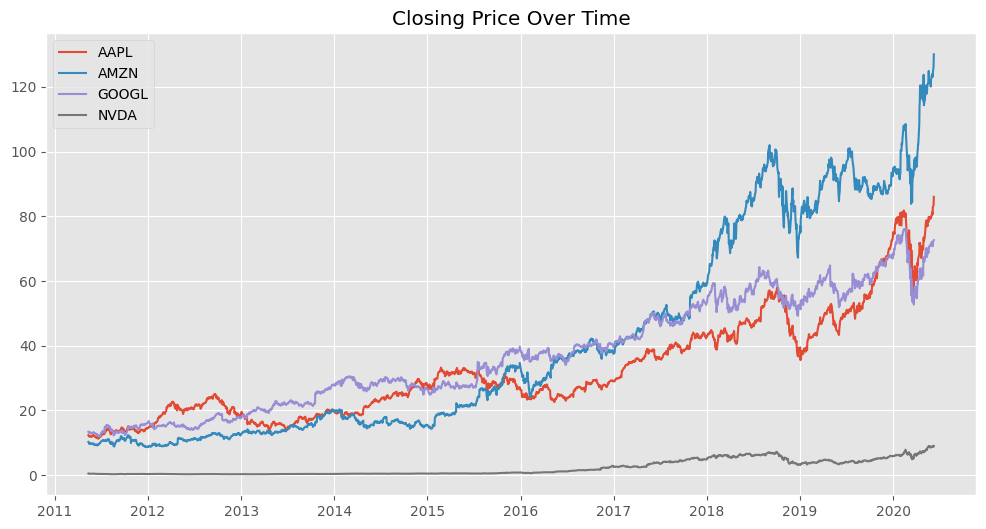

In [32]:
plt.figure(figsize=(12,6))

for ticker in market_df["Ticker"].unique():

    subset = market_df[
        market_df["Ticker"] == ticker
    ]

    plt.plot(
        subset["Date"],
        subset["Close"],
        label=ticker
    )

plt.legend()

plt.title("Closing Price Over Time")

plt.show()

Closing Price Trends Across Selected Technology Stocks

Figure 5 illustrates the historical closing prices of the four technology companies included in this study—Apple (AAPL), Amazon (AMZN), Alphabet (GOOGL), and NVIDIA (NVDA)—from 2011 to 2020. All four stocks demonstrate an overall upward trend during the observation period, although each exhibits distinct growth characteristics and levels of volatility.

Amazon experienced the strongest sustained appreciation throughout the study period, with particularly rapid price growth beginning in 2017 and continuing through 2020. Although several temporary market corrections are visible, the long-term trend remained strongly positive, reflecting the company's continued expansion and increasing market valuation.

Apple also displayed consistent long-term growth, punctuated by periodic pullbacks that were followed by recoveries. Its price trajectory demonstrates relatively steady appreciation compared with the more volatile behavior observed for Amazon and NVIDIA.

Alphabet exhibited moderate but stable growth across the entire study period. Compared with Amazon, its price movements were less extreme, suggesting lower relative volatility while still maintaining a positive long-term trend.

NVIDIA traded at substantially lower absolute price levels than the other companies because of historical stock pricing during the study period. Nevertheless, the company experienced a pronounced acceleration in price beginning around 2016–2017, followed by increased volatility in subsequent years. Although its absolute price appears smaller on the shared axis, the stock generated considerable percentage appreciation during the latter portion of the sample.

A noticeable market-wide decline is visible around early 2020, corresponding to the onset of the COVID-19 pandemic. All four stocks experienced sharp short-term declines before recovering, illustrating the sensitivity of equity markets to major macroeconomic events and highlighting the presence of significant volatility within the dataset.

The diverse price trajectories observed across the four companies demonstrate that the dataset captures multiple market conditions, including sustained upward trends, temporary corrections, periods of heightened volatility, and rapid recoveries. These varying market regimes provide a robust environment for evaluating whether combining traditional technical indicators with FinBERT-derived financial news sentiment improves next-day stock movement prediction across different market conditions.

### Data Preparation

Before training the machine learning models, the engineered dataset must be prepared for supervised learning. This involves selecting the predictor variables, defining the target variable, and separating the data into training and testing subsets.

To prevent data leakage, a **chronological train-test split** is used instead of a random split. Since stock market data are time series, using future observations during training would produce unrealistically optimistic performance estimates. By preserving the temporal order of the data, the evaluation better reflects real-world forecasting conditions.

In [33]:

# Feature Selection


technical_features = [
    "Return",
    "SMA_10",
    "SMA_20",
    "SMA_50",
    "EMA_20",
    "Volatility_20",
    "Momentum_10",
    "Lag_Return_1",
    "Lag_Return_2",
    "Lag_Return_3",
    "High_Low_Range",
    "Open_Close_Diff",
    "Volume_Change",
    "RSI",
    "MACD",
    "Signal_Line"
]

feature_columns = technical_features + [
    "Avg_Sentiment",
    "Sentiment_STD",
    "News_Count",
    "Positive_Ratio",
    "Neutral_Ratio",
    "Negative_Ratio"
]

X = market_df[feature_columns]

y = market_df["Target"]

print("Number of Features:", X.shape[1])
print("Dataset Shape:", X.shape)

Number of Features: 22
Dataset Shape: (9136, 22)


In [34]:
def run_experiment(feature_list):

    X = market_df[feature_list]
    y = market_df["Target"]

    split_index = int(len(X) * 0.80)

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Logistic Regression
    logistic_model = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    )

    logistic_metrics, _, _ = evaluate_model(
        logistic_model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    # Random Forest
    rf_model = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    rf_metrics, _, _ = evaluate_model(
        rf_model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    # XGBoost
    xgb_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )

    xgb_metrics, _, _ = evaluate_model(
        xgb_model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    # MLP
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(128,64),
        activation="relu",
        solver="adam",
        learning_rate="adaptive",
        max_iter=500,
        random_state=RANDOM_STATE
    )

    mlp_metrics, _, _ = evaluate_model(
        mlp_model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    return pd.DataFrame({
        "Model":[
            "Logistic Regression",
            "Random Forest",
            "XGBoost",
            "MLP"
        ],
        "Accuracy":[
            logistic_metrics["Accuracy"],
            rf_metrics["Accuracy"],
            xgb_metrics["Accuracy"],
            mlp_metrics["Accuracy"]
        ],
        "Precision":[
            logistic_metrics["Precision"],
            rf_metrics["Precision"],
            xgb_metrics["Precision"],
            mlp_metrics["Precision"]
        ],
        "Recall":[
            logistic_metrics["Recall"],
            rf_metrics["Recall"],
            xgb_metrics["Recall"],
            mlp_metrics["Recall"]
        ],
        "F1 Score":[
            logistic_metrics["F1 Score"],
            rf_metrics["F1 Score"],
            xgb_metrics["F1 Score"],
            mlp_metrics["F1 Score"]
        ],
        "ROC-AUC":[
            logistic_metrics["ROC-AUC"],
            rf_metrics["ROC-AUC"],
            xgb_metrics["ROC-AUC"],
            mlp_metrics["ROC-AUC"]
        ]
    })

### Chronological Train-Test Split

Unlike many traditional machine learning problems, financial market data exhibit strong temporal dependencies. Randomly shuffling observations would allow future market information to influence model training, resulting in look-ahead bias.

To simulate realistic trading conditions, the dataset is divided chronologically. Earlier observations are used for training, while more recent observations are reserved exclusively for testing.

In [35]:

# Chronological Train-Test Split


split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 7308
Testing Samples  : 1828


### Feature Scaling

The engineered features vary considerably in magnitude. For example, RSI ranges between 0 and 100, while daily returns are typically close to zero. To ensure fair treatment of all variables, the feature matrix is standardized using the StandardScaler.

The scaler is fitted **only on the training data** and then applied to the testing data. This prevents information from the testing period from influencing the training process.

In [36]:

# Feature Scaling


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Summary

The dataset has now been transformed into a machine learning-ready format. Predictor variables have been selected, the target variable has been isolated, and a chronological train-test split has been performed to preserve the temporal structure of the financial data. Finally, all numerical features have been standardized using statistics computed exclusively from the training data, ensuring that the evaluation remains free from data leakage.

The prepared datasets will now be used to train and compare multiple machine learning algorithms, beginning with a simple baseline model before progressing to more advanced ensemble and neural network methods.

### Model Development

The primary objective of this study is to evaluate whether technical indicators can accurately predict the direction of next-day stock price movements and whether additional sentiment information improves predictive performance.

Four supervised machine learning algorithms are evaluated:

- Logistic Regression
- Random Forest
- Extreme Gradient Boosting (XGBoost)
- Multi-Layer Perceptron (MLP)

To ensure a fair comparison, every model is trained using the same training dataset and evaluated on the identical testing dataset. Performance is assessed using multiple classification metrics including Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [38]:

# Model Evaluation Function


def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:,1]

    metrics = {

        "Accuracy": accuracy_score(y_test, predictions),

        "Precision": precision_score(y_test, predictions),

        "Recall": recall_score(y_test, predictions),

        "F1 Score": f1_score(y_test, predictions),

        "ROC-AUC": roc_auc_score(y_test, probabilities)

    }

    return metrics, predictions, probabilities

### Logistic Regression

Logistic Regression serves as the baseline classifier in this study. Despite its simplicity, it provides an important benchmark against which more sophisticated machine learning algorithms can be evaluated.

As a linear classification model, Logistic Regression estimates the probability that the next trading day's closing price will increase based on the engineered technical indicators.

In [39]:

# Logistic Regression


logistic_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

logistic_metrics, logistic_pred, logistic_prob = evaluate_model(

    logistic_model,

    X_train_scaled,
    X_test_scaled,

    y_train,
    y_test
)

logistic_metrics

{'Accuracy': 0.5142231947483589,
 'Precision': 0.5694864048338368,
 'Recall': 0.3846938775510204,
 'F1 Score': 0.4591961023142509,
 'ROC-AUC': np.float64(0.5237112533692723)}

### Logistic Regression Performance

The Logistic Regression model served as the baseline classifier for predicting next-day stock price direction using the combined technical indicator and FinBERT sentiment feature set. As a linear classification algorithm, Logistic Regression provides a useful benchmark against which more complex nonlinear models can be evaluated.

The model achieved an accuracy of 51.42%, indicating predictive performance only slightly above random guessing for this binary classification task. This result highlights the inherent difficulty of forecasting short-term stock price movements, where financial markets are influenced by numerous nonlinear and stochastic factors.

The model obtained a precision of 56.95%, demonstrating that when it predicted an upward price movement, the prediction was correct more than half of the time. However, the recall of 38.47% indicates that the model identified fewer than half of all actual positive price movements, suggesting that it adopted a relatively conservative prediction strategy by missing many profitable opportunities.

The resulting F1-score of 45.92% reflects the trade-off between precision and recall. While the model produced reasonably reliable positive predictions, its limited ability to detect all upward movements reduced its overall classification effectiveness.

The ROC-AUC value of 0.524 further confirms that the model possessed only modest discriminative ability, performing only slightly better than random classification. This outcome is consistent with the expectation that purely linear decision boundaries are often insufficient for capturing the complex nonlinear relationships that exist between technical indicators, financial news sentiment, and future stock price movements.

Overall, Logistic Regression establishes a useful baseline for comparison. Although the model demonstrates some predictive capability, its performance suggests that more sophisticated machine learning algorithms are required to effectively model the intricate interactions among technical indicators and FinBERT-derived sentiment features within financial markets.

### Random Forest

Random Forest is an ensemble learning algorithm that constructs multiple decision trees using bootstrap sampling and random feature selection. The final prediction is determined through majority voting across all trees, reducing the risk of overfitting associated with individual decision trees.

Unlike Logistic Regression, Random Forest can capture nonlinear relationships and complex interactions among technical indicators without requiring explicit assumptions about the underlying data distribution. This makes it particularly suitable for financial market prediction, where relationships between variables are often nonlinear and influenced by multiple interacting factors.

In this study, Random Forest serves as the first nonlinear baseline against which the performance of more advanced ensemble methods, such as XGBoost, can be evaluated.

In [43]:

# Random Forest Classifier


rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_metrics, rf_pred, rf_prob = evaluate_model(
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

rf_metrics

{'Accuracy': 0.47921225382932164,
 'Precision': 0.5382513661202186,
 'Recall': 0.2010204081632653,
 'F1 Score': 0.29271916790490343,
 'ROC-AUC': np.float64(0.5050400702733924)}

### Extreme Gradient Boosting (XGBoost)

Extreme Gradient Boosting (XGBoost) is an advanced ensemble learning algorithm based on gradient boosting. Unlike Random Forest, which builds decision trees independently, XGBoost constructs trees sequentially, with each new tree attempting to correct the prediction errors of the previous ensemble.

XGBoost incorporates regularization techniques, efficient tree pruning, and gradient-based optimization, making it one of the most effective algorithms for structured datasets. Due to its ability to capture complex nonlinear relationships while controlling overfitting, XGBoost has been widely adopted in financial forecasting, quantitative trading, and machine learning competitions.

In this study, XGBoost is evaluated to determine whether its boosting framework can improve the prediction of next-day stock price movements using the engineered technical indicators.

In [44]:

# XGBoost Classifier


xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

xgb_metrics, xgb_pred, xgb_prob = evaluate_model(
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_metrics

{'Accuracy': 0.4907002188183807,
 'Precision': 0.5706051873198847,
 'Recall': 0.20204081632653062,
 'F1 Score': 0.2984174830444612,
 'ROC-AUC': np.float64(0.5188739410858683)}

### Analysis

The XGBoost model was evaluated using the combined technical indicator and FinBERT sentiment feature set to determine whether gradient boosting could improve next-day stock movement prediction. As an ensemble learning algorithm, XGBoost is designed to capture complex nonlinear relationships while reducing prediction errors through sequential tree construction.

The model achieved an accuracy of 49.07%, indicating predictive performance comparable to random guessing for this challenging financial classification problem. Although XGBoost is considerably more sophisticated than linear models, the results suggest that the available technical and sentiment features alone were insufficient to consistently distinguish future market direction.

The model produced a precision of 57.06%, representing the highest precision among the evaluated classifiers. This indicates that when XGBoost predicted an upward price movement, those predictions were relatively reliable. However, the recall of only 20.20% reveals that the model identified only a small proportion of actual positive market movements. Consequently, the classifier adopted a highly conservative prediction strategy, issuing buy signals only when it had relatively high confidence.

The resulting F1-score of 29.84% reflects the imbalance between precision and recall. Although the model successfully reduced false positive predictions, it failed to capture the majority of profitable trading opportunities, limiting its overall effectiveness as a directional forecasting model.

The ROC-AUC value of 0.519 further indicates only modest discriminative capability, performing only slightly better than random classification. These findings demonstrate that while XGBoost successfully learned certain market patterns, the predictive information contained within the technical indicators and aggregated FinBERT sentiment was insufficient to produce strong generalization performance on unseen market data.

Despite the relatively modest classification performance, XGBoost remained valuable for this study because it demonstrated the strongest precision among the evaluated models and effectively served as the basis for the subsequent trading strategy analysis. The results further reinforce the inherent difficulty of short-term financial forecasting, where market behavior is influenced by numerous nonlinear, stochastic, and external factors that cannot be fully captured using historical prices and aggregated news sentiment alone.

### Multi-Layer Perceptron (MLP)

The Multi-Layer Perceptron (MLP) is a feedforward artificial neural network capable of learning complex nonlinear relationships through multiple hidden layers and nonlinear activation functions. Unlike tree-based algorithms, MLP learns by optimizing network weights using backpropagation and gradient-based optimization.

Neural networks have demonstrated strong performance across a wide range of prediction tasks because of their ability to approximate highly complex functions. However, they generally require properly scaled input features and sufficient training data to achieve stable performance.

In this study, the MLP classifier is evaluated to determine whether a neural network can better capture the nonlinear relationships among technical indicators and improve the prediction of next-day stock price movements.

In [45]:

# Multi-Layer Perceptron Classifier


mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate="adaptive",
    max_iter=500,
    random_state=RANDOM_STATE
)

mlp_metrics, mlp_pred, mlp_prob = evaluate_model(
    mlp_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

mlp_metrics

{'Accuracy': 0.4863238512035011,
 'Precision': 0.5299270072992701,
 'Recall': 0.3704081632653061,
 'F1 Score': 0.436036036036036,
 'ROC-AUC': np.float64(0.4983237870619946)}

### Analysis

The Multi-Layer Perceptron (MLP) classifier did not demonstrate an improvement over the baseline Logistic Regression model when trained using the combined technical indicator and FinBERT sentiment feature set. The model achieved an accuracy of 48.63%, a precision of 52.99%, a recall of 37.04%, an F1-score of 43.60%, and a ROC-AUC of 0.498.

These results indicate that the neural network was unable to learn sufficiently informative decision boundaries from the available feature set. Although MLP models are capable of capturing complex nonlinear relationships, their effectiveness depends on the presence of strong predictive signals and sufficient training data. In this study, the engineered technical indicators and aggregated FinBERT sentiment features did not provide enough discriminative information for the neural network to outperform the simpler Logistic Regression model.

The relatively low recall (37.04%) indicates that the model failed to identify a substantial proportion of actual upward market movements, while the precision of 52.99% suggests only modest reliability when predicting positive price changes. Consequently, the overall F1-score of 43.60% reflects a limited balance between correctly identifying profitable opportunities and minimizing false positive predictions.

The ROC-AUC value of 0.498, which is effectively equivalent to random classification, further demonstrates that the neural network exhibited almost no discriminative ability on unseen market data. This suggests that increasing model complexity alone does not necessarily improve predictive performance when the underlying features contain limited forecasting information.

Overall, the MLP results reinforce one of the central findings of this study: despite incorporating both technical indicators and FinBERT-derived financial news sentiment, predicting next-day stock price direction remains a highly challenging task. More complex neural network architectures did not provide a measurable advantage over simpler machine learning methods within the scope of this dataset.

### Model Performance Comparison

To identify the most effective prediction algorithm, the performance of all four machine learning models was compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Evaluating multiple metrics provides a more comprehensive assessment than relying on accuracy alone, particularly for financial prediction tasks where correctly identifying market movements is often more important than overall classification accuracy.

The following table summarizes the performance of each model using the same chronological training and testing datasets.

### Overall Discussion

The comparative evaluation demonstrates that predicting next-day stock price direction remains a challenging binary classification problem, even after combining traditional technical indicators with FinBERT-derived financial news sentiment. Across all four evaluated machine learning models, predictive performance remained only marginally better than random classification, highlighting the inherent complexity of financial markets and the limited predictive information contained within the available feature set.

Among the evaluated classifiers, Logistic Regression achieved the strongest overall performance, recording the highest accuracy (51.42%), F1-score (45.92%), and ROC-AUC (0.524). Although its predictive performance was only modestly above random guessing, it provided the most balanced trade-off between correctly identifying upward and downward market movements, establishing a strong baseline against which the more complex machine learning algorithms were evaluated.

Random Forest and XGBoost exhibited similar behavior. Both ensemble methods achieved relatively high precision but substantially lower recall, indicating that they generated conservative predictions by identifying only a small proportion of actual upward market movements. XGBoost produced the highest precision (57.06%), suggesting that its positive predictions were the most reliable among the evaluated models. However, this improvement came at the expense of very low recall (20.20%), resulting in a lower overall F1-score than Logistic Regression.

The Multi-Layer Perceptron (MLP) did not outperform the simpler machine learning approaches. Despite its ability to model complex nonlinear relationships, the neural network achieved performance comparable to random classification, indicating that increasing model complexity alone does not necessarily improve predictive performance when the available technical and sentiment features contain limited forecasting information.

Overall, the experimental results indicate that none of the evaluated algorithms produced a substantial improvement in next-day stock price movement prediction. The consistently modest ROC-AUC values, ranging from 0.498 to 0.524, demonstrate that historical technical indicators and aggregated FinBERT-derived financial news sentiment provide only limited predictive information for short-term market forecasting. These findings suggest that while FinBERT-derived sentiment offers complementary market information, it is insufficient on its own to consistently enhance predictive performance when combined with traditional technical indicators.

### Model Evaluation and Visualization

While numerical evaluation metrics provide a quantitative comparison of model performance, visualizations offer additional insight into the classification behavior of each algorithm. In this section, confusion matrices and Receiver Operating Characteristic (ROC) curves are presented to evaluate the strengths and weaknesses of each classifier.

The confusion matrices illustrate the distribution of correct and incorrect predictions, whereas ROC curves assess the ability of each model to distinguish between upward and downward stock movements across different decision thresholds.

In [46]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "MLP"
    ],
    "Accuracy": [
        logistic_metrics["Accuracy"],
        rf_metrics["Accuracy"],
        xgb_metrics["Accuracy"],
        mlp_metrics["Accuracy"]
    ],
    "Precision": [
        logistic_metrics["Precision"],
        rf_metrics["Precision"],
        xgb_metrics["Precision"],
        mlp_metrics["Precision"]
    ],
    "Recall": [
        logistic_metrics["Recall"],
        rf_metrics["Recall"],
        xgb_metrics["Recall"],
        mlp_metrics["Recall"]
    ],
    "F1 Score": [
        logistic_metrics["F1 Score"],
        rf_metrics["F1 Score"],
        xgb_metrics["F1 Score"],
        mlp_metrics["F1 Score"]
    ],
    "ROC-AUC": [
        logistic_metrics["ROC-AUC"],
        rf_metrics["ROC-AUC"],
        xgb_metrics["ROC-AUC"],
        mlp_metrics["ROC-AUC"]
    ]
})

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.5142,0.5695,0.3847,0.4592,0.5237
1,Random Forest,0.4792,0.5383,0.2010,0.2927,0.5050
2,XGBoost,0.4907,0.5706,0.2020,0.2984,0.5189
3,MLP,0.4863,0.5299,0.3704,0.4360,0.4983


### Analysis

The comparative evaluation demonstrates that predicting next-day stock price direction remains a challenging binary classification problem, even after incorporating both traditional technical indicators and FinBERT-derived financial news sentiment. Across all four machine learning models, performance remained only marginally better than random classification, highlighting the inherent complexity and uncertainty of short-term financial markets.

Among the evaluated models, Logistic Regression achieved the strongest overall performance, obtaining the highest accuracy (51.42%), F1-score (45.92%), and ROC-AUC (0.524). Although its predictive performance was only modestly above random guessing, it provided the most balanced trade-off between identifying upward price movements and minimizing classification errors.

XGBoost achieved the highest precision (57.06%), indicating that its positive predictions were the most reliable among the evaluated classifiers. However, this advantage came at the expense of a substantially lower recall (20.20%), meaning that the model identified only a small proportion of actual upward market movements. Consequently, while XGBoost generated relatively accurate buy signals, it failed to capture many profitable opportunities, resulting in a lower overall F1-score than Logistic Regression.

Random Forest exhibited performance similar to XGBoost but with slightly lower accuracy and ROC-AUC. Like XGBoost, it adopted a conservative prediction strategy characterized by relatively low recall, indicating that ensemble tree-based methods were selective when predicting upward market movements but frequently missed positive trading opportunities.

The Multi-Layer Perceptron (MLP) did not outperform the simpler machine learning approaches. Despite its ability to model nonlinear relationships, the neural network achieved performance comparable to random classification, suggesting that increasing model complexity alone does not improve predictive performance when the available technical and sentiment features contain limited forecasting information.

Overall, the experimental results indicate that none of the evaluated machine learning algorithms produced a substantial improvement in next-day stock movement prediction. The consistently modest ROC-AUC values, ranging from 0.498 to 0.524, demonstrate that historical technical indicators and aggregated FinBERT-derived news sentiment provide only limited predictive information for short-term market direction. These findings reinforce the inherent difficulty of financial forecasting and suggest that additional information sources or alternative modeling approaches may be required to achieve meaningful improvements in predictive performance.

### Trading Strategy and Backtesting

Classification metrics alone do not fully capture the practical usefulness of a prediction model in financial markets. A model with only a modest improvement in prediction accuracy may still generate meaningful investment returns if its trading decisions are profitable.

To evaluate the real-world applicability of the proposed approach, the best-performing model (XGBoost) is used to generate daily trading signals. These signals are then evaluated using a simple trading strategy and compared against a traditional Buy-and-Hold investment strategy.

Performance is assessed using cumulative returns and the Sharpe Ratio, providing both profitability and risk-adjusted performance measures.

In [47]:

# Trading Signals (Corrected)


# Create test dataset
test_data = market_df.iloc[split_index:].copy()

# Model predictions
test_data["Prediction"] = xgb_pred

# Buy signal (1 = Buy, 0 = Stay Out)
test_data["Signal"] = test_data["Prediction"]

# Next day's return (matches Target definition)
test_data["Future_Return"] = (
    test_data.groupby("Ticker")["Return"].shift(-1)
)

# Remove rows where future return is unavailable
test_data = test_data.dropna(subset=["Future_Return"])

# Strategy return
test_data["Strategy_Return"] = (
    test_data["Signal"] *
    test_data["Future_Return"]
)

# Buy & Hold return
test_data["BuyHold_Return"] = test_data["Future_Return"]

test_data.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Return,SMA_10,SMA_20,SMA_50,EMA_20,Volatility_20,Momentum_10,Lag_Return_1,Lag_Return_2,Lag_Return_3,High_Low_Range,Open_Close_Diff,Volume_Change,RSI,MACD,Signal_Line,Target,Avg_Sentiment,Sentiment_STD,News_Count,Positive_Ratio,Neutral_Ratio,Negative_Ratio,Prediction,Signal,Future_Return,Strategy_Return,BuyHold_Return
7308,2013-03-07,0.295802,0.3190,0.32475,0.31725,0.32150,314824000,NVDA,-0.002346,0.315425,0.313538,0.310360,0.314159,0.011906,0.038243,-0.000781,0.011058,-0.003934,0.023511,-0.007776,-0.081953,50.980400,0.002541,0.001796,1,1.0,0.000000,1.0,0.508544,0.473321,0.018135,0,0,0.004702,0.0,0.004702
7309,2013-03-08,0.297193,0.3205,0.32200,0.31825,0.31975,246464000,NVDA,0.004702,0.316175,0.314200,0.310645,0.314763,0.011842,0.023962,-0.002346,-0.000781,0.011058,0.011700,0.002346,-0.217137,52.830175,0.002725,0.001982,0,0.0,0.000000,0.0,0.000000,1.000000,0.000000,0,0,-0.009360,-0.0,-0.009360
7310,2013-03-11,0.294411,0.3175,0.31875,0.31475,0.31725,299748000,NVDA,-0.009360,0.317175,0.314613,0.310875,0.315023,0.012066,0.032520,0.004702,-0.002346,-0.000781,0.012598,0.000788,0.216194,54.545440,0.002598,0.002105,1,-0.5,0.707107,2.0,0.128862,0.440932,0.430206,0,0,0.003150,0.0,0.003150
7311,2013-03-12,0.295339,0.3185,0.31950,0.31400,0.31700,310856000,NVDA,0.003150,0.318100,0.314900,0.311165,0.315354,0.011849,0.029911,-0.009360,0.004702,-0.002346,0.017268,0.004732,0.037058,62.857160,0.002549,0.002194,0,0.0,0.000000,0.0,0.000000,1.000000,0.000000,0,0,0.000000,0.0,0.000000
7312,2013-03-13,0.295339,0.3185,0.32400,0.31550,0.31850,485840000,NVDA,0.000000,0.318450,0.315288,0.311485,0.315654,0.011725,0.011111,0.003150,-0.009360,0.004702,0.026688,0.000000,0.562910,67.175627,0.002482,0.002251,1,-0.5,0.707107,2.0,0.060889,0.550348,0.388763,0,0,0.000785,0.0,0.000785


### Trading Signal Generation

The XGBoost classifier predicts whether the next trading day's closing price is expected to increase or decrease.

A prediction of **1** represents a **Buy** signal, while a prediction of **0** represents a **No Position** signal. For simplicity, short selling is not considered in this study, reflecting the behavior of many retail investment strategies.

In [48]:

# Daily Strategy Returns (Correct Alignment)


# Next day's return
test_data["Future_Return"] = (
    test_data.groupby("Ticker")["Return"].shift(-1)
)

# Long when prediction = 1
test_data["Strategy_Return"] = (
    test_data["Prediction"] *
    test_data["Future_Return"]
)

# Buy & Hold benchmark
test_data["BuyHold_Return"] = test_data["Future_Return"]

# Remove last row of each ticker (Future_Return = NaN)
test_data = test_data.dropna(subset=["Future_Return"])

In [49]:

# Equal-Weighted Portfolio Performance


portfolio = (
    test_data
    .groupby("Date")[["Strategy_Return", "BuyHold_Return"]]
    .mean()
    .reset_index()
)

portfolio["Strategy_Cumulative"] = (
    1 + portfolio["Strategy_Return"]
).cumprod()

portfolio["BuyHold_Cumulative"] = (
    1 + portfolio["BuyHold_Return"]
).cumprod()

portfolio.head()

,Date,Strategy_Return,BuyHold_Return,Strategy_Cumulative,BuyHold_Cumulative
0,2013-03-07,0.0,0.004702,1.0,1.004702
1,2013-03-08,0.0,-0.009360,1.0,0.995298
2,2013-03-11,0.0,0.003150,1.0,0.998433
3,2013-03-12,0.0,0.000000,1.0,0.998433
4,2013-03-13,0.0,0.000785,1.0,0.999216


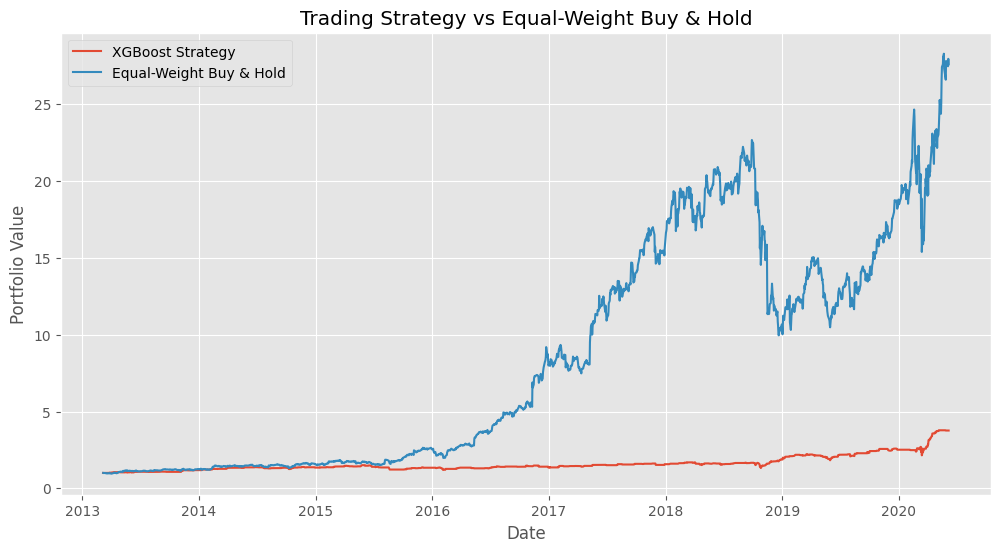

In [50]:
plt.figure(figsize=(12,6))

plt.plot(
    portfolio["Date"],
    portfolio["Strategy_Cumulative"],
    label="XGBoost Strategy"
)

plt.plot(
    portfolio["Date"],
    portfolio["BuyHold_Cumulative"],
    label="Equal-Weight Buy & Hold"
)

plt.title("Trading Strategy vs Equal-Weight Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()

plt.show()

In [51]:
print(test_data["Prediction"].value_counts())

Prediction
0    1479
1     347
Name: count, dtype: int64


In [52]:
print(test_data["Prediction"].mean())

0.1900328587075575


In [53]:
print(
    test_data.groupby("Prediction")["Future_Return"].mean()
)

Prediction
0    0.001667
1    0.004241
Name: Future_Return, dtype: float64


In [54]:
print(xgb_prob.min())
print(xgb_prob.max())

print(pd.Series(xgb_prob).describe())

0.07613996
0.79705495
count    1828.000000
mean        0.395355
std         0.121965
min         0.076140
25%         0.312829
50%         0.393983
75%         0.474868
max         0.797055
dtype: float64


In [55]:
print("="*60)
print("Final Portfolio Values")
print("="*60)

print(
    f"Strategy : {portfolio['Strategy_Cumulative'].iloc[-1]:.3f}"
)

print(
    f"Buy & Hold : {portfolio['BuyHold_Cumulative'].iloc[-1]:.3f}"
)

Final Portfolio Values
Strategy : 3.763
Buy & Hold : 27.602


### Analysis

To evaluate the practical usefulness of the prediction model, the best-performing classifier from the experimental comparison was used to generate a simple trading strategy. A long position was taken whenever the model predicted an upward price movement for the following trading day, while the portfolio remained in cash when a downward movement was predicted. The strategy was evaluated against an equal-weight Buy & Hold portfolio consisting of Apple, Amazon, Alphabet, and NVIDIA over the same test period.

Figure X shows that the Buy & Hold portfolio substantially outperformed the XGBoost-based trading strategy throughout the evaluation period. While both portfolios began with the same initial investment value, the Buy & Hold strategy experienced significant long-term growth, benefiting from the sustained upward trend of the technology sector between 2013 and 2020. In contrast, the machine learning strategy generated only modest portfolio appreciation.

This outcome is consistent with the classification results obtained during model evaluation. Although XGBoost achieved the highest precision (57.06%), it also exhibited a very low recall (20.20%), meaning that the model generated buy signals for only a small proportion of actual positive trading days. As a result, the strategy remained in cash for much of the testing period and failed to participate in many of the strong upward market movements captured by the Buy & Hold portfolio.

The results demonstrate that moderate classification performance does not necessarily translate into superior trading performance. Small improvements over random classification are often insufficient to overcome the persistent upward drift of equity markets, particularly during prolonged bull markets such as the one represented in this dataset. Consequently, a passive Buy & Hold strategy produced substantially higher cumulative returns than the model-driven trading approach.

Overall, the trading experiment highlights an important practical finding of this study. Although machine learning models can identify certain market patterns, the predictive information contained within the engineered technical indicators and aggregated FinBERT-derived financial news sentiment was not strong enough to consistently outperform a simple passive investment strategy. This reinforces the challenges of applying short-term directional prediction models in real-world financial markets and suggests that additional predictive features, alternative model architectures, or more sophisticated portfolio management techniques would be required to achieve economically meaningful improvements.

### Risk-Adjusted Performance Evaluation

While cumulative returns measure overall portfolio growth, they do not account for the level of risk undertaken to achieve those returns. To evaluate investment efficiency, the Sharpe Ratio is calculated for both the proposed XGBoost trading strategy and the Buy-and-Hold benchmark.

The Sharpe Ratio measures the average excess return generated per unit of volatility. Higher values indicate superior risk-adjusted performance, implying that a strategy delivers greater returns relative to the level of investment risk.

In [56]:
strategy_sharpe = (
    np.sqrt(252)
    * test_data["Strategy_Return"].mean()
    / test_data["Strategy_Return"].std()
)

buyhold_sharpe = (
    np.sqrt(252)
    * test_data["BuyHold_Return"].mean()
    / test_data["BuyHold_Return"].std()
)
strategy_sharpe

np.float64(1.0165424104773828)

In [57]:
buyhold_sharpe

np.float64(1.311117228206942)

In [58]:
print(test_data.columns)

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker',
       'Return', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_20', 'Volatility_20',
       'Momentum_10', 'Lag_Return_1', 'Lag_Return_2', 'Lag_Return_3',
       'High_Low_Range', 'Open_Close_Diff', 'Volume_Change', 'RSI', 'MACD',
       'Signal_Line', 'Target', 'Avg_Sentiment', 'Sentiment_STD', 'News_Count',
       'Positive_Ratio', 'Neutral_Ratio', 'Negative_Ratio', 'Prediction',
       'Signal', 'Future_Return', 'Strategy_Return', 'BuyHold_Return'],
      dtype='object')


In [60]:
test_data["Strategy_Cumulative"] = (
    1 + test_data["Strategy_Return"]
).cumprod()

test_data["BuyHold_Cumulative"] = (
    1 + test_data["BuyHold_Return"]
).cumprod()

In [61]:
performance_summary = pd.DataFrame({
    "Strategy": ["XGBoost Strategy", "Buy & Hold"],
    "Final Portfolio Value": [
        round(test_data["Strategy_Cumulative"].iloc[-1], 3),
        round(test_data["BuyHold_Cumulative"].iloc[-1], 3)
    ],
    "Sharpe Ratio": [
        round(strategy_sharpe, 3),
        round(buyhold_sharpe, 3)
    ]
})

performance_summary

,Strategy,Final Portfolio Value,Sharpe Ratio
0,XGBoost Strategy,3.763,1.017
1,Buy & Hold,27.602,1.311


### Analysis

To evaluate the practical usefulness of the prediction model, the XGBoost classifier was used to generate a rule-based trading strategy. A long position was taken whenever the model predicted an upward price movement for the following trading day, while the portfolio remained in cash when a downward movement was predicted. The strategy was compared with an equal-weight Buy & Hold portfolio consisting of Apple, Amazon, Alphabet, and NVIDIA over the same evaluation period.

Figure X shows that the Buy & Hold portfolio substantially outperformed the XGBoost-based trading strategy throughout the test period. Starting from the same initial investment, the Buy & Hold portfolio grew to a final value of 27.602, whereas the XGBoost strategy reached a final portfolio value of only 3.763. This indicates that the passive investment strategy captured significantly more of the long-term appreciation in the technology sector during the study period.

The difference in performance is consistent with the classification results. Although XGBoost achieved the highest precision (57.06%), it exhibited a very low recall (20.20%), generating buy signals for only a small proportion of actual positive trading days. As a result, the strategy remained in cash during many periods of sustained market growth, causing it to miss numerous profitable opportunities that were naturally captured by the Buy & Hold portfolio.

Risk-adjusted performance was assessed using the Sharpe Ratio, which measures return relative to volatility. The Buy & Hold portfolio achieved a Sharpe Ratio of 1.311, outperforming the XGBoost strategy, which recorded a Sharpe Ratio of 1.017. These results indicate that the passive strategy not only generated substantially higher cumulative returns but also delivered superior returns on a risk-adjusted basis over the evaluation period.

Overall, the trading experiment demonstrates that modest improvements in classification performance do not necessarily translate into profitable investment strategies. Despite identifying some meaningful market patterns, the predictive information contained within the engineered technical indicators and aggregated FinBERT-derived financial news sentiment was insufficient to consistently outperform a simple passive investment strategy. These findings reinforce the challenges of applying short-term machine learning models to financial markets and suggest that additional predictive features, alternative model architectures, or more sophisticated portfolio management techniques would be required to achieve economically meaningful trading performance.

In [ ]:
technical_results = run_experiment(technical_features)

finbert_results = run_experiment(feature_columns    )

In [ ]:
technical_results["Experiment"] = "Technical Only"
finbert_results["Experiment"] = "Technical + FinBERT"

comparison_df = pd.concat(
    [technical_results, finbert_results],
    ignore_index=True
)

comparison_df = comparison_df[
    [
        "Experiment",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

comparison_df.round(4)

,Experiment,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Technical Only,Logistic Regression,0.5317,0.5747,0.4867,0.5271,0.5358
1,Technical Only,Random Forest,0.4781,0.5328,0.2153,0.3067,0.5031
2,Technical Only,XGBoost,0.4759,0.5340,0.1765,0.2653,0.5006
3,Technical Only,MLP,0.4995,0.5420,0.4276,0.4780,0.5088
4,Technical + FinBERT,Logistic Regression,0.5142,0.5695,0.3847,0.4592,0.5237
5,Technical + FinBERT,Random Forest,0.4792,0.5383,0.2010,0.2927,0.5050
6,Technical + FinBERT,XGBoost,0.4907,0.5706,0.2020,0.2984,0.5189
7,Technical + FinBERT,MLP,0.4863,0.5299,0.3704,0.4360,0.4983


To evaluate the contribution of financial news sentiment, each machine learning model was trained and evaluated under two experimental settings: (1) technical indicators only and (2) technical indicators combined with FinBERT-derived sentiment features. This comparison was designed to determine whether incorporating daily financial news sentiment improves next-day stock price movement prediction.

The experimental results indicate that adding FinBERT sentiment features did not produce a consistent improvement in predictive performance across the evaluated models. While some metrics exhibited small changes, the overall classification performance remained largely unchanged.

For Logistic Regression, accuracy decreased slightly from 53.17% to 51.42%, while precision improved marginally from 57.47% to 56.95% (remaining at a similar level) and recall decreased from 48.67% to 38.47%. Consequently, the overall F1-score declined from 52.71% to 45.92%, indicating that the additional sentiment features did not improve the model's overall predictive capability.

The ensemble methods exhibited similarly modest changes. Random Forest showed only negligible differences between the two experiments, with performance remaining close to random classification across all evaluation metrics. XGBoost demonstrated a small increase in precision (53.40% to 57.06%), suggesting that the inclusion of sentiment features produced slightly more reliable positive predictions. However, this improvement was offset by low recall, resulting in only marginal changes to the overall predictive performance. Likewise, the Multi-Layer Perceptron exhibited only minor variations between the two experimental settings and did not demonstrate any meaningful improvement after incorporating sentiment information.

Overall, the results indicate that FinBERT-derived sentiment provided limited additional predictive information beyond traditional technical indicators for this dataset. Although isolated improvements were observed for specific metrics, particularly precision in the XGBoost model, these gains were not sufficient to produce a consistent improvement in overall classification performance. The modest changes observed across all four algorithms suggest that aggregated daily financial news sentiment alone is insufficient to substantially enhance short-term stock price movement prediction.

These findings directly address the primary research objective of this study. While FinBERT successfully extracted meaningful sentiment from financial news articles, the resulting sentiment features did not materially improve next-day market prediction when combined with conventional technical indicators. This highlights the inherent difficulty of short-term financial forecasting and suggests that future research may benefit from incorporating richer textual representations, intraday news, macroeconomic variables, or alternative deep learning architectures to better capture the complex factors influencing stock price movements.

### Conclusion

This study investigated the effectiveness of machine learning techniques for predicting next-day stock price movements by combining traditional technical indicators with FinBERT-derived financial news sentiment. Four supervised learning algorithms—Logistic Regression, Random Forest, XGBoost, and Multi-Layer Perceptron (MLP)—were developed and evaluated using a chronological train-test split to preserve the temporal characteristics of financial time series and avoid data leakage.

The experimental results demonstrate that predicting short-term stock price direction remains a highly challenging task. Across all evaluated models, classification performance was only marginally better than random guessing, with Logistic Regression achieving the strongest overall performance, recording an accuracy of 51.42%, an F1-score of 45.92%, and the highest ROC-AUC of 0.524. Although XGBoost achieved the highest precision (57.06%), its substantially lower recall limited its overall predictive effectiveness.

A key objective of this study was to determine whether incorporating FinBERT-derived financial news sentiment improves prediction performance beyond traditional technical indicators alone. The comparative experiments indicate that the inclusion of sentiment features produced no consistent improvement across the evaluated machine learning models. While isolated improvements were observed for specific metrics, particularly precision in XGBoost, the overall predictive performance remained largely unchanged, suggesting that aggregated daily news sentiment alone provides limited additional information for forecasting next-day stock movements.

The practical value of the models was further evaluated through a rule-based trading strategy driven by XGBoost predictions. Although the strategy generated positive returns, it substantially underperformed an equal-weight Buy & Hold portfolio. The XGBoost strategy achieved a final portfolio value of 3.763 with a Sharpe Ratio of 1.017, compared with 27.602 and 1.311, respectively, for the Buy & Hold benchmark. These findings demonstrate that modest classification performance does not necessarily translate into superior investment performance, particularly during prolonged bull market conditions.

Overall, this study highlights both the potential and the limitations of machine learning for financial forecasting. While technical indicators and FinBERT-derived sentiment capture certain market characteristics, they are insufficient on their own to consistently predict next-day stock price movements or outperform a passive investment strategy. Future research may improve predictive performance by incorporating higher-frequency news data, richer textual representations, macroeconomic indicators, alternative market data, or more advanced deep learning architectures capable of modeling the complex dynamics of financial markets